In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
%run NRlib.ipynb

In [44]:
t,y=integrate(deriv,t_span,y0,0.01,args=None, method=explicit_midpoint, extra_par=None)

NameError: name 'deriv' is not defined

In [215]:
def deriv(y,t,args=None):
    dy_dt=-y
    return dy_dt

In [216]:
def true(t):
    return np.exp(-t)

In [217]:
y0=1
t_fin=1
t_span = [0,t_fin]

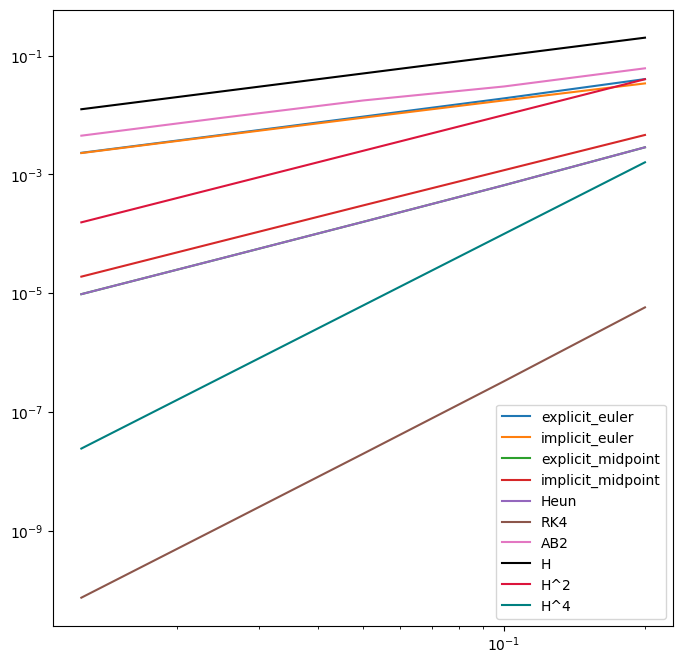

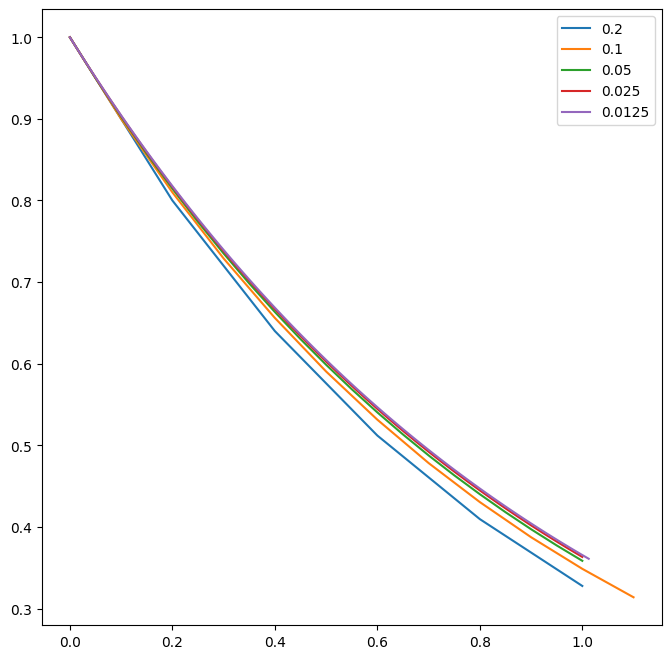

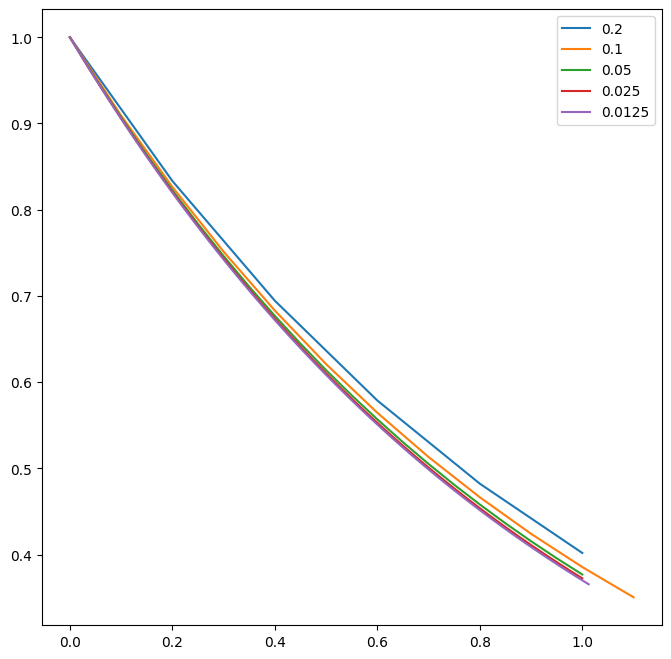

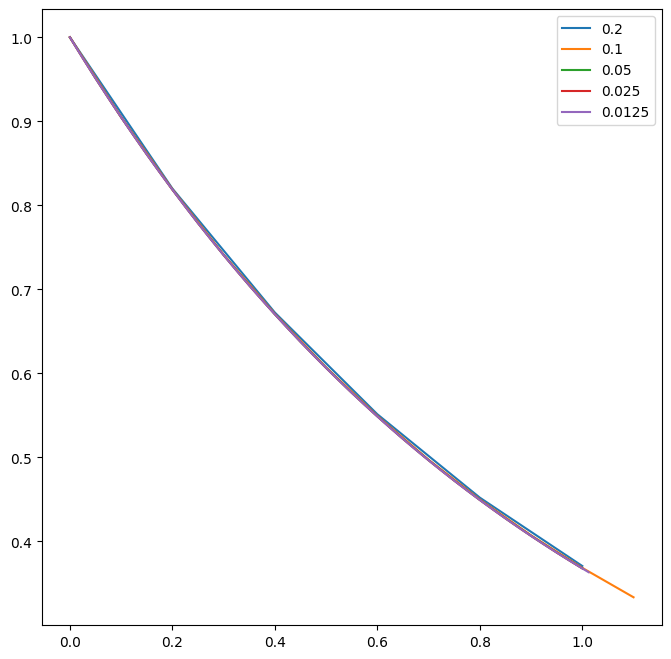

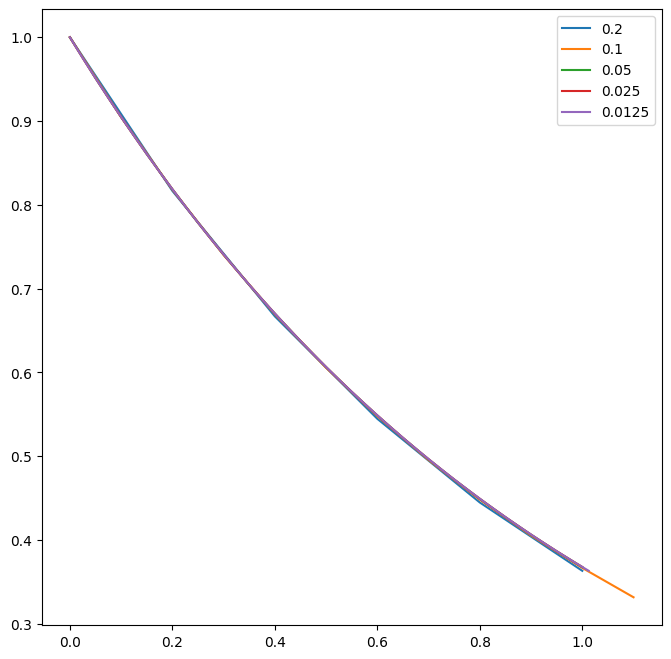

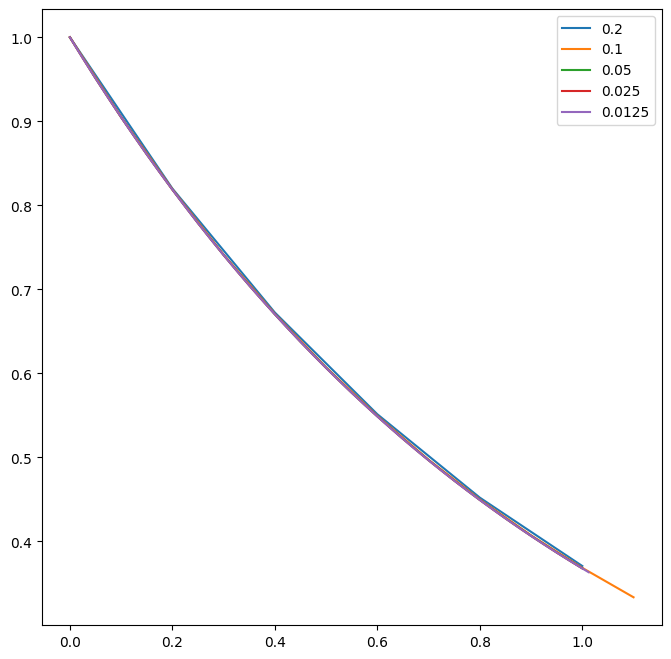

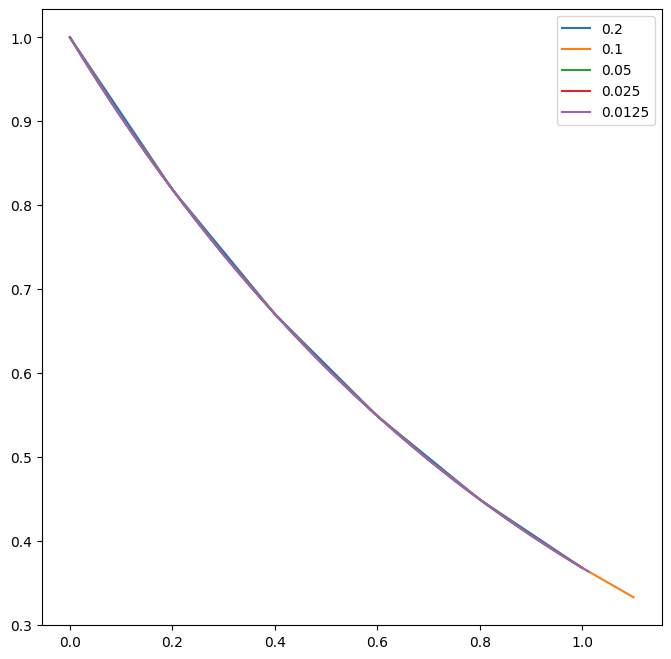

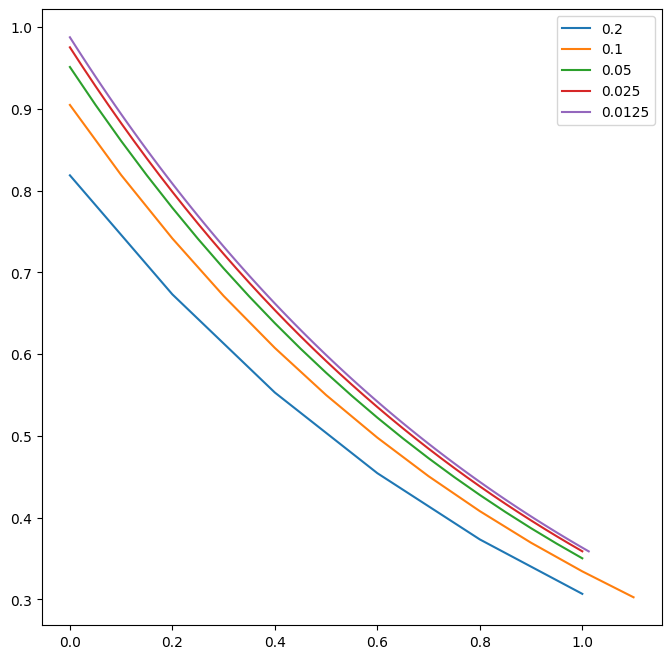

In [223]:
methods=[explicit_euler,implicit_euler,explicit_midpoint,implicit_midpoint,Heun, RK4, AB2]
names=["explicit_euler","implicit_euler","explicit_midpoint","implicit_midpoint","Heun","RK4", "AB2"]
H=np.array([0.2, 0.1, 0.05, 0.025, 0.0125])

fig1=plt.figure(figsize=[8,8])
ax1=fig1.add_subplot(111)
for i in range(len(methods)):
    errv=np.array([])
    fig2=plt.figure(figsize=[8,8])
    ax2=fig2.add_subplot(111)
    for j in range(len(H)):
        h=H[j]
        
        if i<=5:
            t,y=integrate(deriv,t_span,y0,h,args=None, method=methods[i], extra_par=None)
        
        else:
            t,y=integrate(deriv,t_span,true(t_span[0]+h),h,args=None, method=AB2, extra_par=y0)
        
        err=np.abs(y[-1]-true(t[-1]))
        errv=np.append(errv,err)
        ax2.plot(t,y,label=str(h))
        ax2.legend(loc='best')
        
    ax1.plot(H,errv,label=names[i])
    ax1.set_xscale('log')
    ax1.set_yscale('log')

ax1.plot(H,H,label='H', c='k')
ax1.plot(H,H**2,label='H^2', c='crimson')
ax1.plot(H,H**4,label='H^4', c='teal')
ax1.legend(loc='best')

[0.  0.2 0.4 0.6 0.8 1. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1]
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.   ]
[0.     0.0125 0.025  0.0375 0.05   0.0625 0.075  0.0875 0.1    0.1125
 0.125  0.1375 0.15   0.1625 0.175  0.1875 0.2    0.2125 0.225  0.2375
 0.25   0.2625 0.275  0.2875 0.3    0.3125 0.325  0.3375 0.35   0.3625
 0.375  0.3875 0.4    0.4125 0.425  0.4375 0.45   0.4625 0.475  0.4875
 0.5    0.5125 0.525  0.5375 0.55   0.5625 0.575  0.5875 0.6    0.6125
 0.625  0.6375 0.65   0.6625 0.675  0.6875 0.7    0.7125 0.725  0.7375
 0.75   0.7625 0.775  0.7875 0.8    0.8125 0.825  0.8375 0.85   0.8625
 0.875  0.8875 0.9    0.9125 0.925  0.9375 0.95   0.9625 0.975  0.98

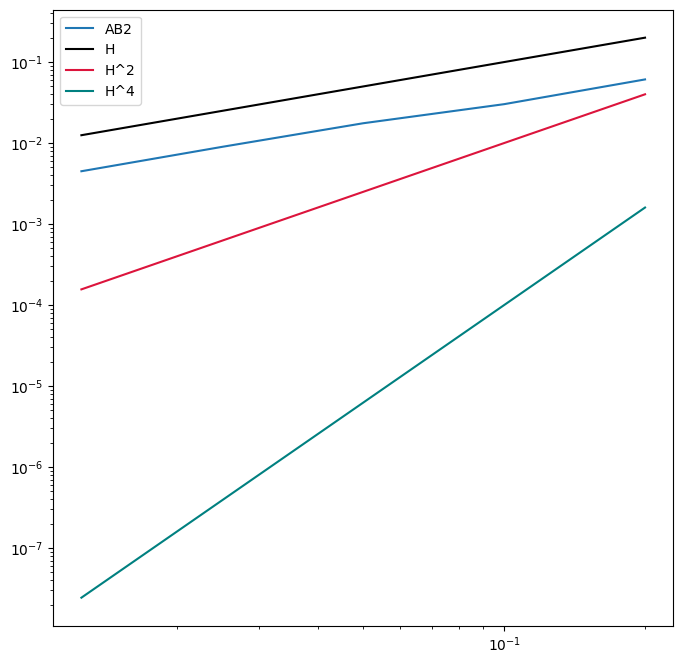

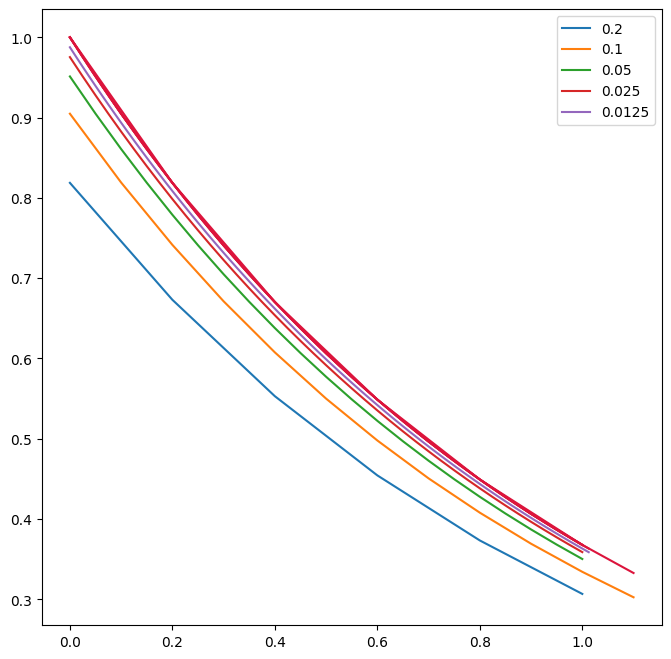

In [224]:
H=np.array([0.2, 0.1, 0.05, 0.025, 0.0125])

fig1=plt.figure(figsize=[8,8])
ax1=fig1.add_subplot(111)
fig2=plt.figure(figsize=[8,8])
ax2=fig2.add_subplot(111)
errv=np.array([])

for j in range(len(H)):
    h=H[j]
    #print(true(t+h))
    t,y=integrate(deriv,t_span,true(t_span[0]+h),h,args=None, method=AB2, extra_par=y0)
    ax2.plot(t,y, label=str(h))
    ax2.plot(t,np.exp(-t), c='crimson')
    print(t)
    err=np.abs(y[-1]-true(t[-1]))
    errv=np.append(errv,err)

        
        #ax2.plot(t,y)
ax2.legend(loc='best')
        
    #print(errv)
ax1.plot(H,errv, label='AB2')
ax1.plot(H,H,label='H', c='k')
ax1.plot(H,H**2,label='H^2', c='crimson')
ax1.plot(H,H**4,label='H^4', c='teal')
ax1.legend(loc='best')

ax1.set_xscale('log')
ax1.set_yscale('log')

# 2

In [235]:
p=[1,1,2,2]
c=[2,0,0.5,0]

In [249]:
lmax=-1000
lmin=-1

S=np.abs(lmax/lmin)

err_rel=0.01
t_slow=5

h_stuff=np.zeros([4,2])

for i in range(len(p)):
    h_acc=t_slow*err_rel**(1/p[i])
    penalty=S*err_rel**(1/p[i])
    h_stab=c[i]/np.abs(lmax)
    h_stuff[i][1]=h_acc
    h_stuff[i][0]=h_stab

print(h_stuff)

[[0.002  0.05  ]
 [0.     0.05  ]
 [0.0005 0.5   ]
 [0.     0.5   ]]


In [263]:
def f(y,t,args=None):
    deriv=np.array([-y[0],-1000*y[1]])
    return deriv

In [281]:
def u_prime(u,v):
    return 998*u+1998*v

def v_prime(u,v):
    return -999*u-1999*v

def f(y,t,args=None):
    u,v=y
    return np.array([u_prime(u,v),v_prime(u,v)])

In [282]:
def u(t):
    return 2*np.exp(-t)-np.exp(-1000*t) 

def v(t):
    return -np.exp(-t)+np.exp(-1000*t)

In [283]:
y0=np.array([1,0])
t_span=[0,5]

C:\Users\insta\AppData\Local\Temp\ipykernel_23084\1137405762.py:2: RuntimeWarning: overflow encountered in scalar multiply
  return 998*u+1998*v
C:\Users\insta\AppData\Local\Temp\ipykernel_23084\1137405762.py:5: RuntimeWarning: overflow encountered in scalar multiply
  return -999*u-1999*v
C:\Users\insta\AppData\Local\Temp\ipykernel_23084\1137405762.py:2: RuntimeWarning: invalid value encountered in scalar add
  return 998*u+1998*v
C:\Users\insta\AppData\Local\Temp\ipykernel_23084\1137405762.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  return -999*u-1999*v


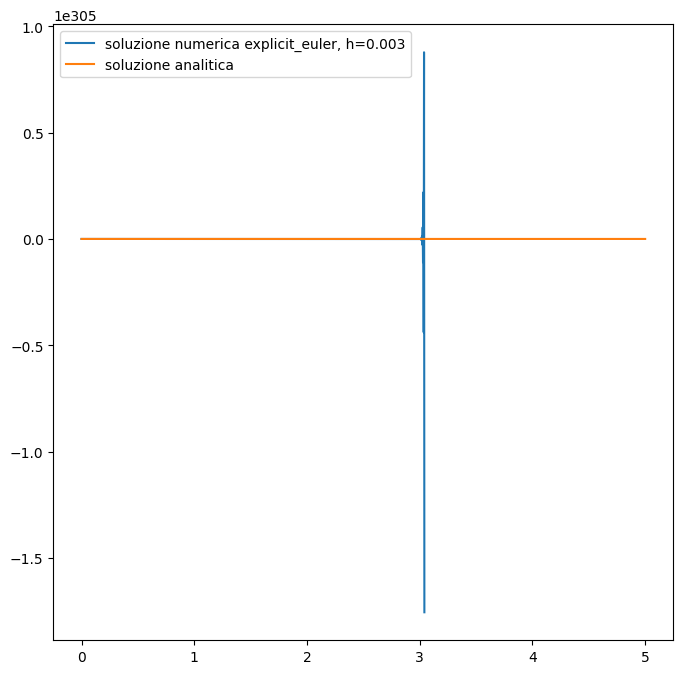

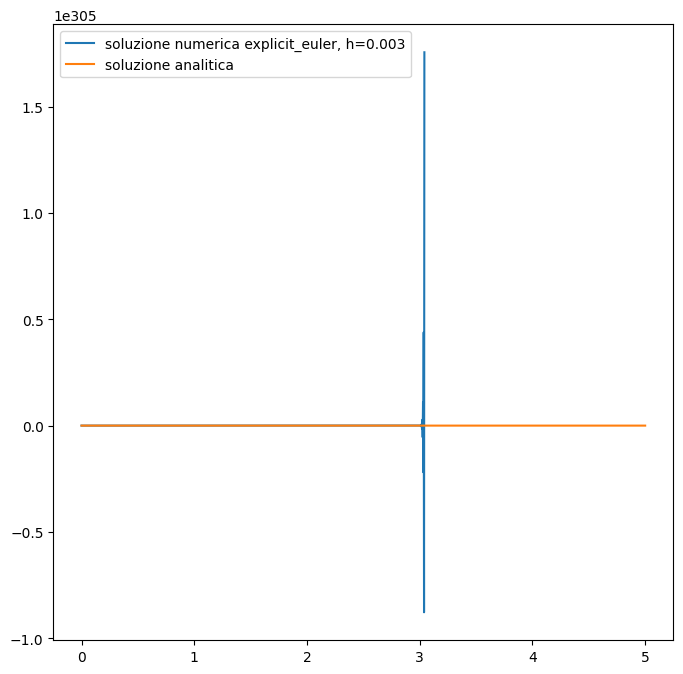

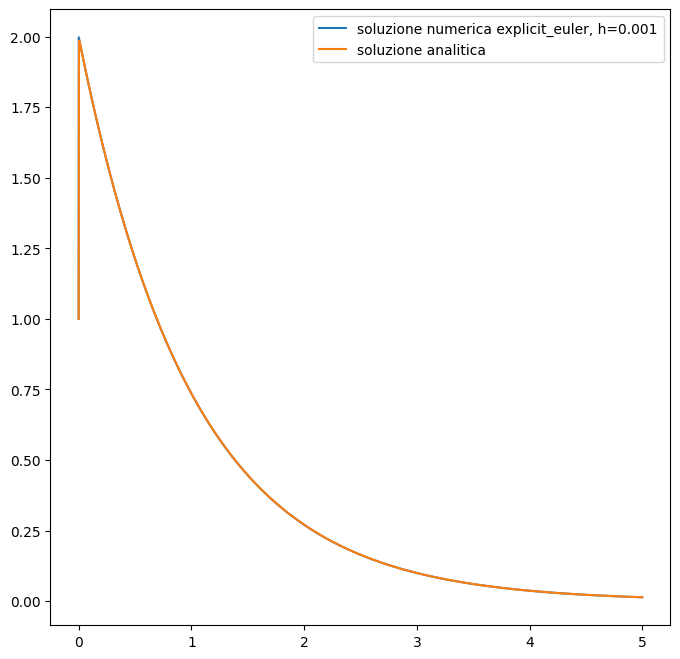

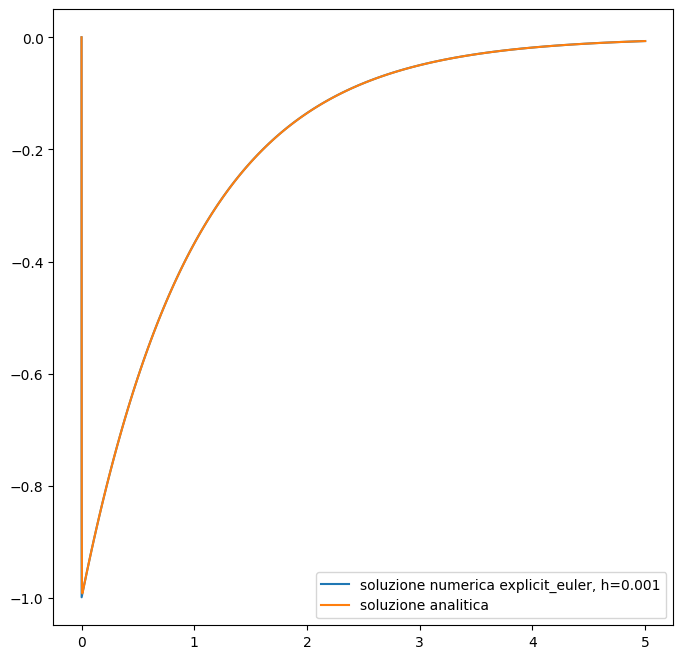

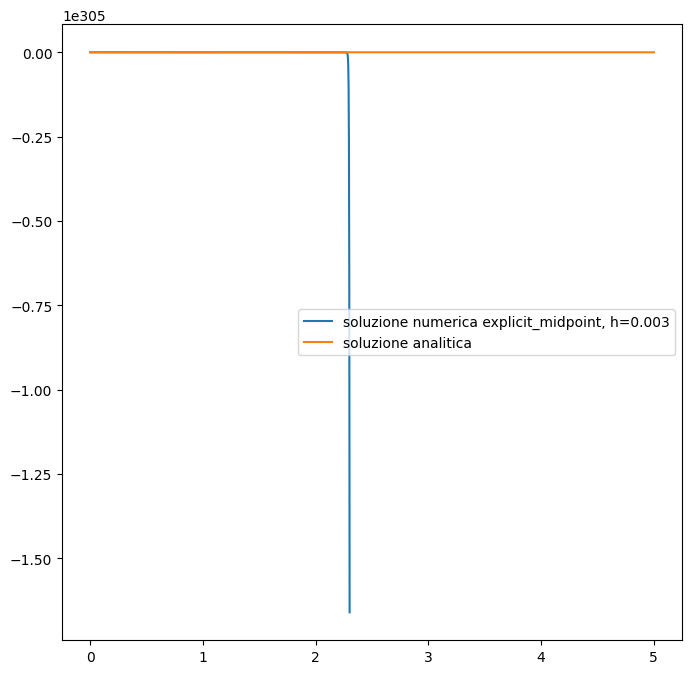

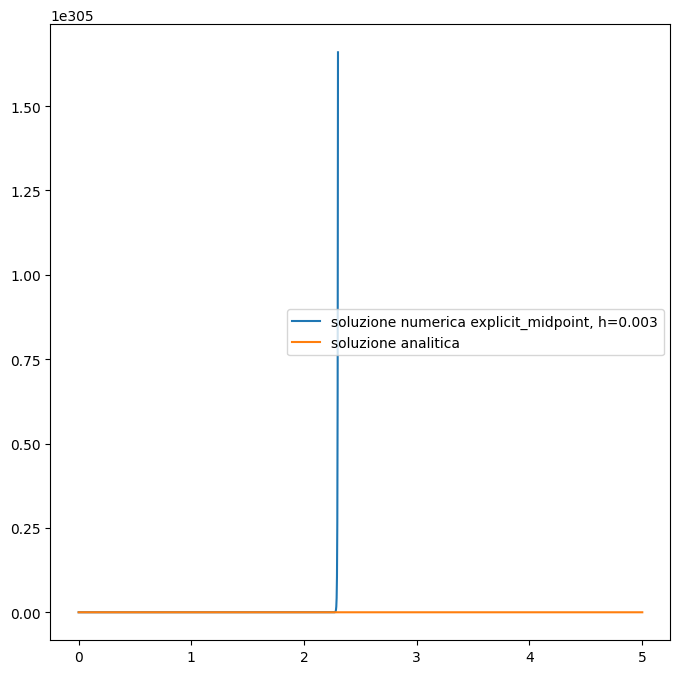

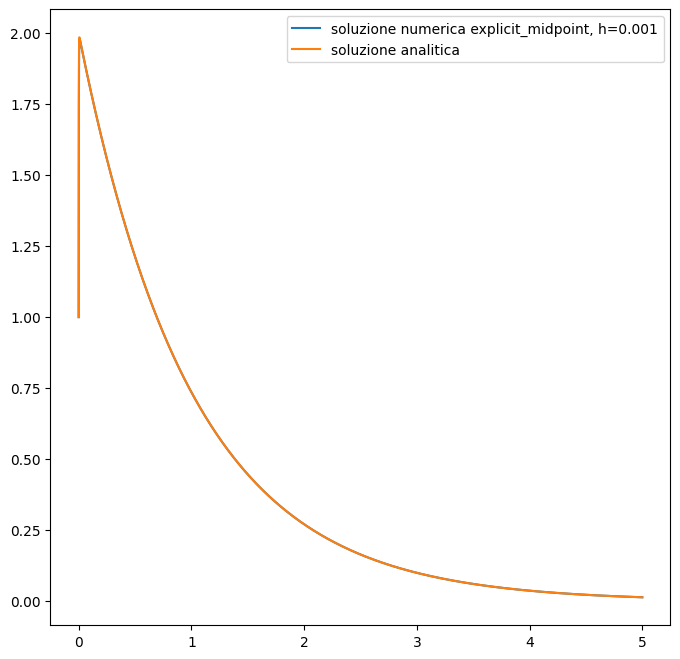

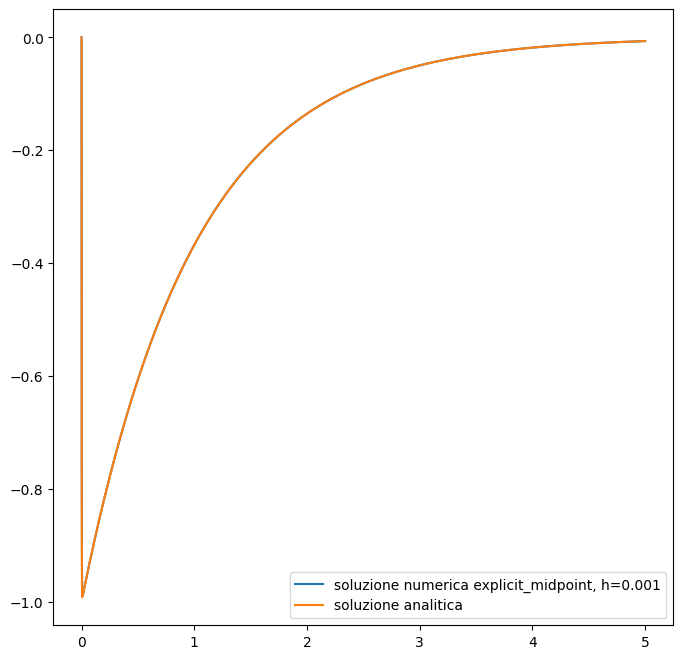

In [290]:
H=[0.003,0.001]
methods=[explicit_euler,explicit_midpoint]
names=["explicit_euler","explicit_midpoint"]
for i in range(len(methods)):
    for h in H:
        t,y=integrate(f,t_span,y0,h,args=None, method=methods[i], extra_par=None)
        fig1=plt.figure(figsize=[8,8])
        ax1=fig1.add_subplot(111)
        ax1.plot(t,y[0],label='soluzione numerica '+str(names[i])+', h='+str(h))
        ax1.plot(t,u(t),label='soluzione analitica')
        #ax1.set_xscale('log')
        #ax1.set_yscale('log')
        ax1.legend(loc='best')
        
        fig2=plt.figure(figsize=[8,8])
        ax2=fig2.add_subplot(111)
        ax2.plot(t,y[1],label='soluzione numerica '+str(names[i])+', h='+str(h))
        ax2.plot(t,v(t),label='soluzione analitica')
        #ax2.set_xscale('log')
        #ax2.set_yscale('log')
        ax2.legend(loc='best')

In [291]:
H=np.linspace(0.01,0,1,5)
for h in H:
        t,y=integrate(f,t_span,y0,h,args=None, method=implicit_euler, extra_par=None)
        fig1=plt.figure(figsize=[8,8])
        ax1=fig1.add_subplot(111)
        ax1.plot(t,y[0],label='soluzione numerica, h='+str(h))
        ax1.plot(t,u(t),label='soluzione analitica')
        #ax1.set_xscale('log')
        #ax1.set_yscale('log')
        ax1.legend(loc='best')
        
        fig2=plt.figure(figsize=[8,8])
        ax2=fig2.add_subplot(111)
        ax2.plot(t,y[1],label='soluzione numerica, h='+str(h))
        ax2.plot(t,v(t),label='soluzione analitica')
        #ax2.set_xscale('log')
        #ax2.set_yscale('log')
        ax2.legend(loc='best')

TypeError: cannot unpack non-iterable numpy.float64 object

In [303]:
def func(y,t,args):
    g,l=args
    theta,omega=y
    dtheta=omega
    domega=-g/l*np.sin(theta)
    return np.array([dtheta,domega])

In [310]:
import scipy

l=1
g=10
args=np.array([g,l])

y0=[0.5,0]

k=np.sin(y0[0]/2)**2

T=4*scipy.special.ellipk(k)*np.sqrt(l/g)
Norb=100
h=T/Norb

t_span=[0,T*100]

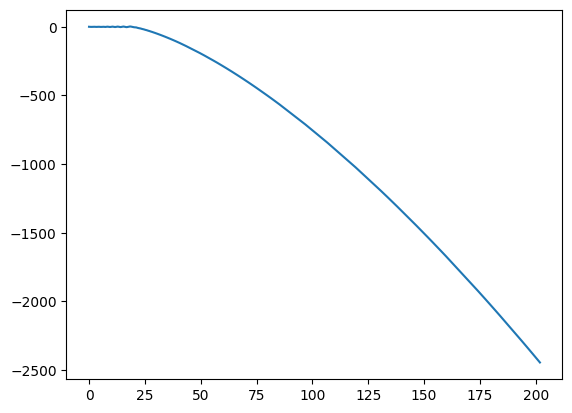

In [317]:
t,y=integrate(func,t_span,y0,h,args=args, method=explicit_euler, extra_par=None)
plt.plot(t,y[0])

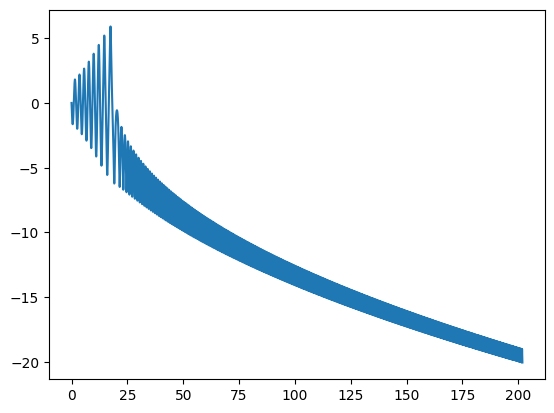

In [318]:
plt.plot(t,y[1])

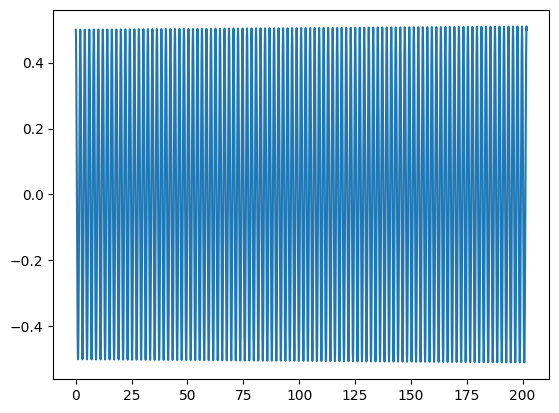

In [319]:
t,y=integrate(func,t_span,y0,h,args=args, method=explicit_midpoint, extra_par=None)
plt.plot(t,y[0])

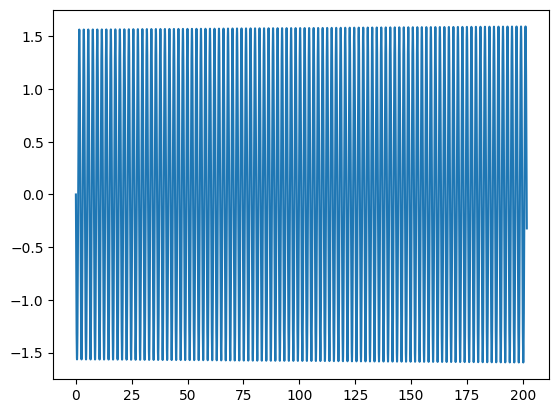

In [320]:
plt.plot(t,y[1])

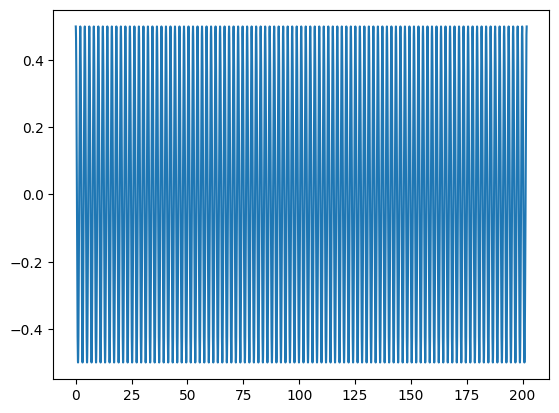

In [314]:
t,y=integrate(func,t_span,y0,h,args=args, method=RK4, extra_par=None)
plt.plot(t,y[0])

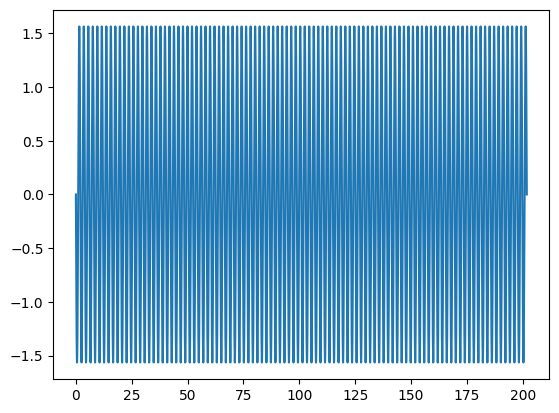

In [316]:
plt.plot(t,y[1])

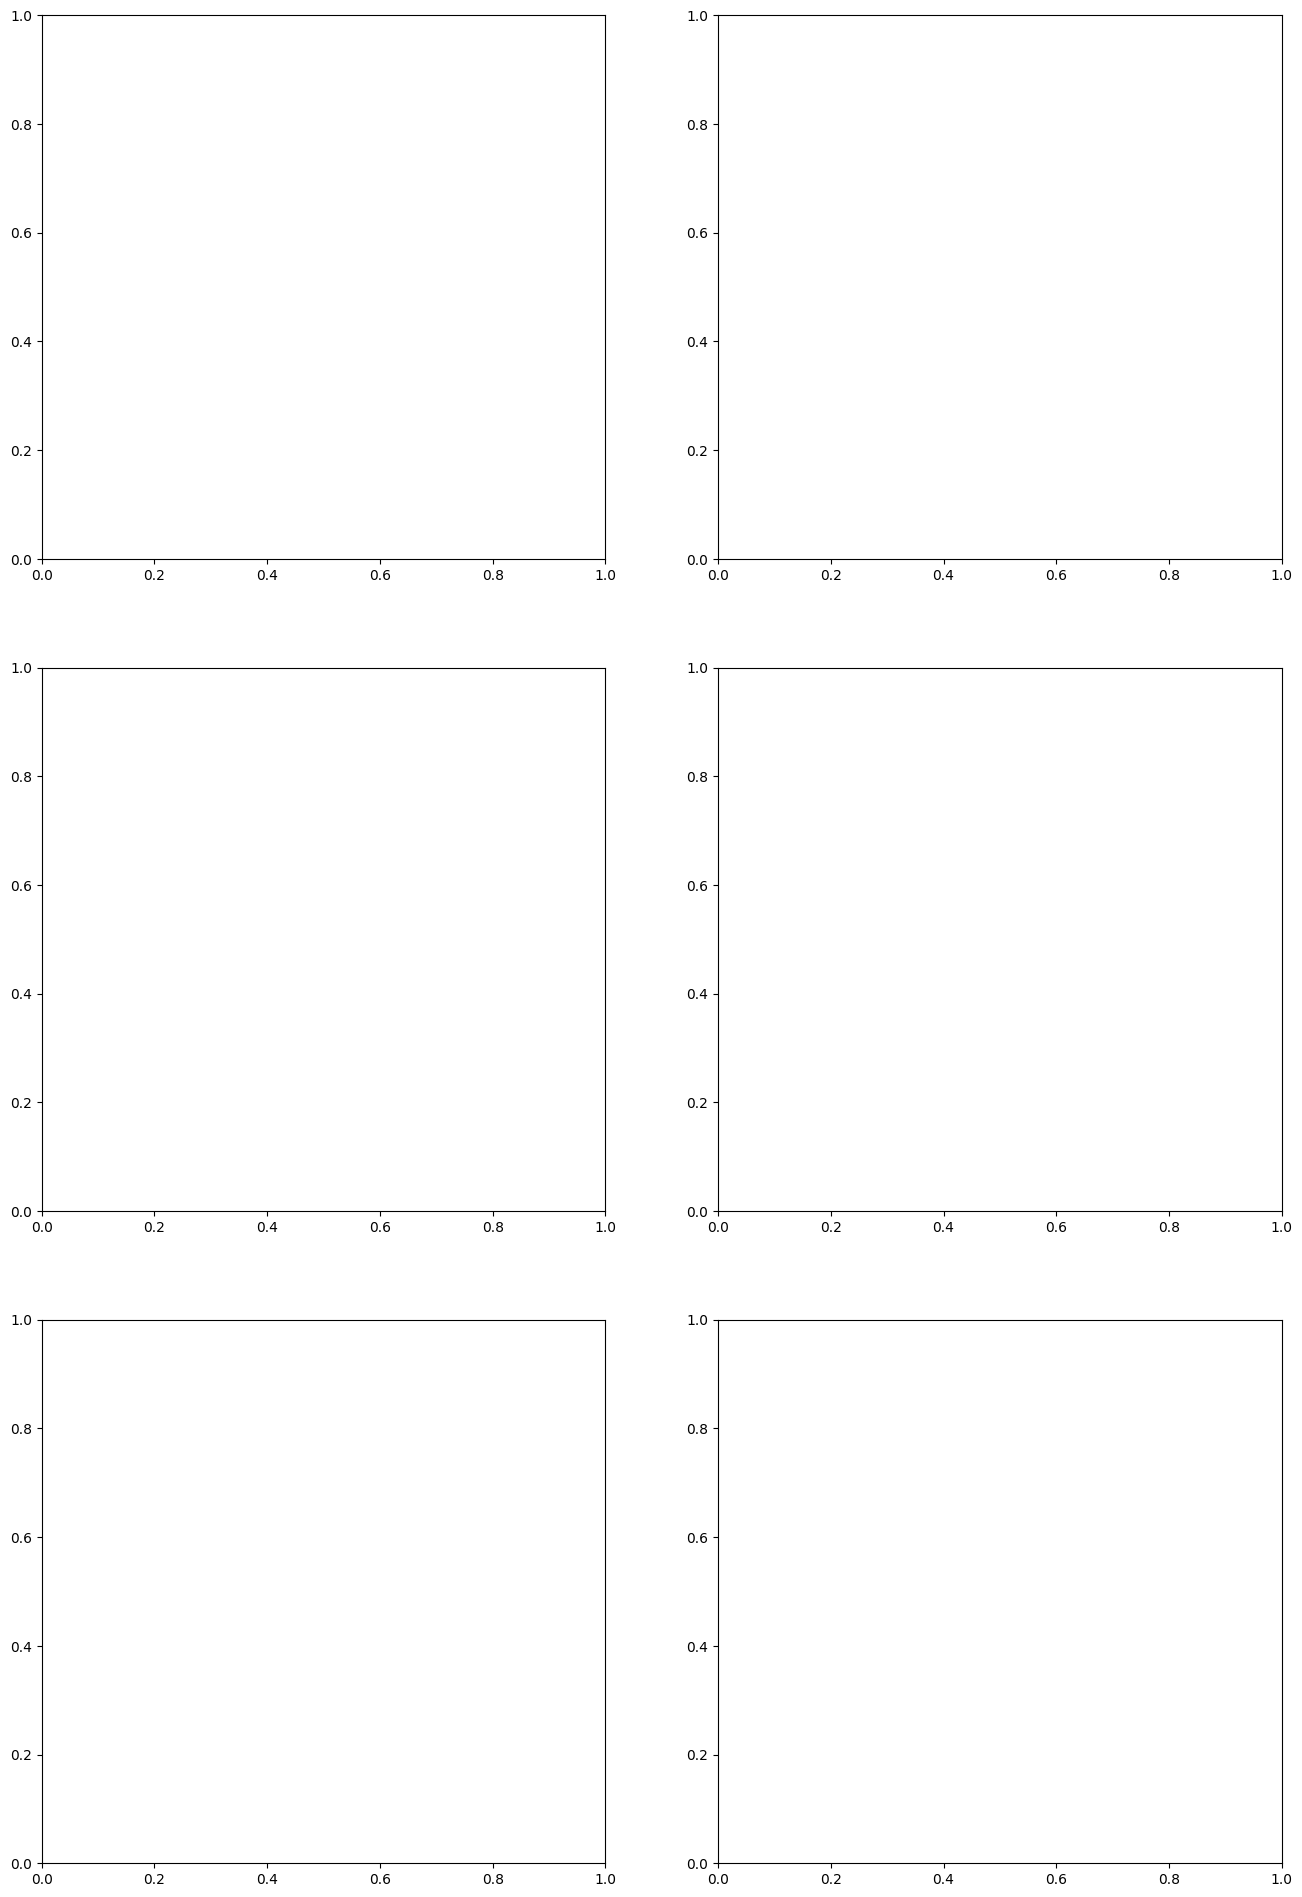

In [323]:
fig1=plt.figure(figsize=[16,24])
ax1=fig1.add_subplot(321)
ax2=fig1.add_subplot(322)
ax3=fig1.add_subplot(323)
ax4=fig1.add_subplot(324)
ax5=fig1.add_subplot(325)
ax6=fig1.add_subplot(326)

In [9]:
import scipy

m=1
l=1
g=10
args=np.array([g,l])

y0=[0.5,0]

k=np.sin(y0[0]/2)**2

T=4*scipy.special.ellipk(k)*np.sqrt(l/g)
Norb=100
h=T/Norb

t_span=[0,T*100]

args=np.array([m,g,l])

In [34]:
def func(y,t,args):
    m,g,l=args
    theta,omega=y
    dtheta=omega
    domega=-m*g/l*np.sin(theta)
    return np.array([dtheta,domega])

In [35]:
def gradV(q,args):
    m,g,l=args
    return -m*g*l*np.cos(q)

In [60]:
t,y=integrate(func,t_span,y0,h,args=args, method=leapfrog, extra_par=None)

[0.5 0. ]
[-4.79425539]
[[0.49902341]]


ValueError: not enough values to unpack (expected 2, got 1)

# 2 BODY PROBLEM